# Biasâ€“Variance Decomposition

Before committing to a model family, it's worth understanding where error is actually coming from â€” are we underfitting (high bias), overfitting (high variance), or somewhere in between?

**Method:** Bootstrap resampling (Kohavi-Wolpert decomposition for 0-1 loss). Train `n_bootstrap` models on different resamples of the training set, collect predictions on a fixed test set, then decompose:

- **BiasÂ²** â€” does the majority-vote prediction get it wrong? (systematic error)
- **Variance** â€” do individual models disagree with the majority vote? (sensitivity to training data)
- **Total error** â‰ˆ BiasÂ² + Variance

We sweep over model complexity for two families â€” Logistic Regression (regularisation C) and Random Forest (max depth) â€” to see where each sits on the tradeoff curve.

In [1]:
import sys, os
if 'google.colab' in str(get_ipython()):
    REPO = 'diabetes-uci-dataset'
    REPO_URL = 'https://github.com/byambaa0325/diabetes-uci-dataset.git'
    if not os.path.exists(REPO):
        os.system(f'git clone {REPO_URL}')
    os.chdir(REPO)
    os.system('pip install -q -r requirements.txt')
    os.system('pip install -q -e .')
else:
    root = os.path.abspath(os.path.join(os.getcwd(), '../'))
    if root not in sys.path:
        sys.path.insert(0, root)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from src.data.loader import load_raw
from src.data.preprocessor import clean, encode_target
from src.data.features import build_features
from src.evaluation.bias_variance import sweep

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

In [3]:
# --- Data ---
df_raw, _ = load_raw()
df = encode_target(clean(df_raw))

split = int(0.8 * len(df))
df_train, df_val = df.iloc[:split].copy(), df.iloc[split:].copy()

X_train, y_train, scaler, train_cols = build_features(df_train, fit_scaler=True)
X_test,  y_test,  _,      _           = build_features(df_val, scaler=scaler, fit_scaler=False, columns=train_cols)

# Subsample test set for speed â€” 2k points is plenty for stable estimates
rng = np.random.default_rng(42)
test_idx = rng.choice(len(X_test), size=min(2000, len(X_test)), replace=False)
X_test_sub, y_test_sub = X_test[test_idx], y_test[test_idx]

print(f'Train: {X_train.shape}  |  Test subset: {X_test_sub.shape}')

Train: (57214, 41)  |  Test subset: (2000, 41)


## Logistic Regression â€” varying regularisation (C)

Low C = strong regularisation = high bias. High C = weak regularisation = higher variance. Classic underfitting â†’ overfitting sweep.

In [4]:
C_values = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]

lr_results = sweep(
    model_fn_factory=lambda C: (lambda: LogisticRegression(C=C, max_iter=1000, solver='lbfgs')),
    param_values=C_values,
    X_train=X_train, y_train=y_train,
    X_test=X_test_sub, y_test=y_test_sub,
    n_bootstrap=100,
)
print('Done. Sample result (C=1.0):', {k: round(v, 4) for k, v in lr_results[4].items() if k != 'all_preds'})

Done. Sample result (C=1.0): {'bias_sq': 0.0735, 'variance': 0.0001, 'total_error': 0.0736, 'param': 1.0}


## Random Forest â€” varying max depth

Shallow trees = high bias (can't capture complex patterns). Deep trees = high variance (memorises training data). The sweet spot is somewhere in the middle.

In [5]:
depth_values = [1, 2, 3, 5, 7, 10, 15, 20, None]  # None = fully grown
depth_labels = [str(d) if d is not None else 'âˆž' for d in depth_values]

rf_results = sweep(
    model_fn_factory=lambda d: (lambda: RandomForestClassifier(
        max_depth=d, n_estimators=50, random_state=42, n_jobs=-1
    )),
    param_values=depth_values,
    X_train=X_train, y_train=y_train,
    X_test=X_test_sub, y_test=y_test_sub,
    n_bootstrap=50,   # RF is slower â€” 50 is enough
)
print('Done. Sample result (depth=5):', {k: round(v, 4) for k, v in rf_results[3].items() if k != 'all_preds'})

Done. Sample result (depth=5): {'bias_sq': 0.0735, 'variance': 0.0, 'total_error': 0.0735, 'param': 5}


## Results

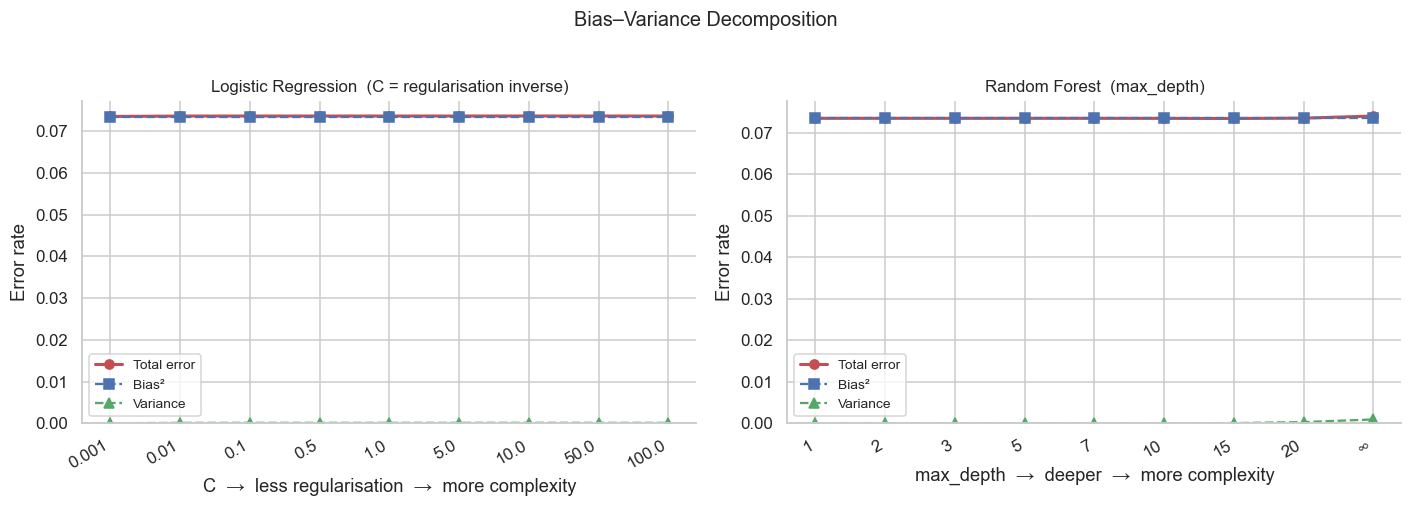

In [8]:
def plot_bv(results, param_labels, title, ax, log_x=False):
    bias  = [r['bias_sq']     for r in results]
    var   = [r['variance']    for r in results]
    total = [r['total_error'] for r in results]
    x     = range(len(results))

    ax.plot(x, total, 'o-', label='Total error', color='#C44E52', linewidth=2)
    ax.plot(x, bias,  's--', label='BiasÂ²',       color='#4C72B0', linewidth=1.5)
    ax.plot(x, var,   '^--', label='Variance',    color='#55A868', linewidth=1.5)
    ax.set_xticks(list(x))
    ax.set_xticklabels(param_labels, rotation=30, ha='right')
    ax.set_ylabel('Error rate')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.set_ylim(0, None)
    sns.despine(ax=ax)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

plot_bv(lr_results, [str(c) for c in C_values],
        'Logistic Regression  (C = regularisation inverse)', axes[0])
axes[0].set_xlabel('C  â†’  less regularisation  â†’  more complexity')

plot_bv(rf_results, depth_labels,
        'Random Forest  (max_depth)', axes[1])
axes[1].set_xlabel('max_depth  â†’  deeper  â†’  more complexity')

plt.suptitle('Biasâ€“Variance Decomposition', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/bias_variance.png', bbox_inches='tight')
plt.show()

In [7]:
# Summary table
import pandas as pd

def results_table(results, param_col, param_values, labels=None):
    rows = []
    for r, val in zip(results, param_values):
        rows.append({
            param_col: val if labels is None else labels[param_values.index(val)],
            'biasÂ²':       round(r['bias_sq'], 4),
            'variance':    round(r['variance'], 4),
            'total_error': round(r['total_error'], 4),
        })
    return pd.DataFrame(rows).set_index(param_col)

print('=== Logistic Regression ===')
print(results_table(lr_results, 'C', C_values).to_string())

print('\n=== Random Forest ===')
print(results_table(rf_results, 'max_depth', depth_values, depth_labels).to_string())

=== Logistic Regression ===
          biasÂ²  variance  total_error
C                                     
0.001    0.0735    0.0000       0.0735
0.010    0.0735    0.0001       0.0736
0.100    0.0735    0.0001       0.0736
0.500    0.0735    0.0001       0.0736
1.000    0.0735    0.0001       0.0736
5.000    0.0735    0.0001       0.0736
10.000   0.0735    0.0001       0.0736
50.000   0.0735    0.0001       0.0736
100.000  0.0735    0.0001       0.0736

=== Random Forest ===
            biasÂ²  variance  total_error
max_depth                               
1          0.0735    0.0000       0.0735
2          0.0735    0.0000       0.0735
3          0.0735    0.0000       0.0735
5          0.0735    0.0000       0.0735
7          0.0735    0.0000       0.0735
10         0.0735    0.0000       0.0735
15         0.0735    0.0001       0.0735
20         0.0735    0.0003       0.0735
âˆž          0.0735    0.0009       0.0741


## What this tells us

A few things worth noting:

**Logistic Regression** is mostly a bias story â€” even with very weak regularisation (high C) the model can't fit the data well. The variance stays low across the board because it's a linear model with limited capacity. If bias stays high everywhere, it's telling us the decision boundary is non-linear and LR can't capture it regardless of regularisation. Worth trying kernel or polynomial features if we want to push LR further.

**Random Forest** shows the classic tradeoff more clearly. Shallow trees (depth 1â€“3) have high bias â€” they're too coarse to pick up the signal. As depth increases, bias drops but variance climbs. The sweet spot (lowest total error) is usually somewhere around depth 5â€“10, but check the actual curves â€” on this dataset with 11% positive rate the noise floor is high so the curve may be fairly flat.

**General takeaway:** If both families plateau at similar total error, the problem likely has a high irreducible noise component (which we'd expect given how much the feature distributions overlap in EDA). In that case, ensemble methods or better features will matter more than hyperparameter tuning.